# Real NKI Option A: Preprocessed fMRI → Connectomes → CPM

This notebook is designed for your Ubuntu/VS Code `connectome` project.

**Goal:** use real preprocessed NKI-Rockland resting-state fMRI data, derive subject connectomes, and run CPM **only if** a suitable behavioral target such as trait anxiety is available.

Important honesty note: the easy public NKI neuroimaging releases often include imaging plus limited/basic phenotype fields. Rich psychiatric/behavioral variables may require a Data Usage Agreement (DUA). This notebook therefore includes a strong phenotype-column inspection step before modeling.


In [1]:
from pathlib import Path
import sys
import subprocess
import importlib.util

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
PHENO_DIR = DATA_DIR / "phenotypes"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

for d in [RAW_DIR, PROCESSED_DIR, PHENO_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)
print("Processed:", PROCESSED_DIR)
print("Phenotypes:", PHENO_DIR)
print("Results:", RESULTS_DIR)
print("Figures:", FIGURES_DIR)


Project root: /home/john-walkey/Data/Research/connectome
Python: /home/john-walkey/Data/Research/connectome/.venv/bin/python
Processed: /home/john-walkey/Data/Research/connectome/data/processed
Phenotypes: /home/john-walkey/Data/Research/connectome/data/phenotypes
Results: /home/john-walkey/Data/Research/connectome/results
Figures: /home/john-walkey/Data/Research/connectome/figures


## 1. Check required packages

This notebook uses `nilearn` to fetch a small NKI enhanced preprocessed dataset. If `nilearn` is missing, run the install cell below once, then restart the kernel.


In [2]:
required = ["numpy", "pandas", "matplotlib", "scipy", "sklearn", "nilearn"]
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]

print("Missing packages:", missing)

# Uncomment and run if needed:
# subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy", "pandas", "matplotlib", "scipy", "scikit-learn", "nilearn", "nibabel"])


Missing packages: []


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import LeaveOneOut
from nilearn import datasets, surface, signal

np.random.seed(42)


## 2. Fetch real NKI preprocessed surface fMRI

This uses Nilearn's `fetch_surf_nki_enhanced`, which downloads preprocessed resting-state fMRI projected to the fsaverage5 surface.

Start with **24 subjects** because that matches your earlier question. Later you can increase this.


In [4]:
N_SUBJECTS = 24

nki = datasets.fetch_surf_nki_enhanced(
    n_subjects=N_SUBJECTS,
    data_dir=str(RAW_DIR / "nilearn_data"),
    resume=True,
    verbose=1
)

print(nki.keys())
print("Number left files:", len(nki.func_left))
print("Number right files:", len(nki.func_right))


[fetch_surf_nki_enhanced] Dataset found in /home/john-walkey/Data/Research/connectome/data/raw/nilearn_data/nki_enhanced_surface
dict_keys(['func_left', 'func_right', 'phenotypic', 'description'])
Number left files: 24
Number right files: 24


## 3. Save and inspect available phenotypes

Before doing CPM, we must know what behavioral columns are actually available.

Look carefully at the printed columns. We will search for candidate anxiety/STAI-like columns, but you may need richer DUA phenotype data for true trait anxiety.


In [5]:
pheno = pd.DataFrame(nki.phenotypic)
pheno.to_csv(PHENO_DIR / "nki_nilearn_public_phenotypes.csv", index=False)

print("Phenotype shape:", pheno.shape)
print("\nColumns:")
for i, col in enumerate(pheno.columns):
    print(f"{i:03d}: {col}")

display(pheno.head())
print("Saved:", PHENO_DIR / "nki_nilearn_public_phenotypes.csv")


Phenotype shape: (23, 4)

Columns:
000: Subject
001: Age
002: Dominant Hand
003: Sex


,Subject,Age,Dominant Hand,Sex
0,A00033747,27.0,R,F
1,A00035072,38.0,R,F
2,A00035827,38.0,R,M
3,A00035840,25.0,R,F
4,A00037112,36.0,R,F


Saved: /home/john-walkey/Data/Research/connectome/data/phenotypes/nki_nilearn_public_phenotypes.csv


In [6]:
search_terms = ["anx", "stai", "trait", "state", "worry", "fear", "neurotic", "emotion", "stress", "depress"]
candidate_cols = [c for c in pheno.columns if any(term in str(c).lower() for term in search_terms)]

print("Candidate anxiety/emotion-related columns:")
for col in candidate_cols:
    print("-", col)

if not candidate_cols:
    print("\nNo obvious anxiety/STAI-like columns found in this public Nilearn subset.")
    print("That does NOT mean NKI lacks rich phenotyping; it likely means this easy public subset does not expose the variable you want.")


Candidate anxiety/emotion-related columns:

No obvious anxiety/STAI-like columns found in this public Nilearn subset.
That does NOT mean NKI lacks rich phenotyping; it likely means this easy public subset does not expose the variable you want.


## 4. Build simple real-data connectomes

For a first Option A notebook, we avoid raw fMRI preprocessing. The data are already preprocessed surface time series.

To create a manageable connectome, we divide each hemisphere's fsaverage5 surface vertices into coarse parcels and average the time series within each parcel.

**Important limitation:** these are not anatomical ROIs yet. This is a first real-data CPM pipeline. Once this works, the next upgrade is an anatomical/parcellation-based atlas with labels such as insula, DMN, salience, and executive networks.


In [7]:
N_PARCELS_PER_HEMISPHERE = 50
N_PARCELS = N_PARCELS_PER_HEMISPHERE * 2

def make_equal_vertex_parcels(n_vertices, n_parcels):
    labels = np.zeros(n_vertices, dtype=int)
    splits = np.array_split(np.arange(n_vertices), n_parcels)
    for i, idx in enumerate(splits):
        labels[idx] = i
    return labels

def load_and_parcellate_surface(left_file, right_file, n_parcels_per_hemi=50):
    left = surface.load_surf_data(left_file)
    right = surface.load_surf_data(right_file)

    # Nilearn surface data are usually vertices x time.
    if left.shape[0] < left.shape[1]:
        left = left.T
    if right.shape[0] < right.shape[1]:
        right = right.T

    left_labels = make_equal_vertex_parcels(left.shape[0], n_parcels_per_hemi)
    right_labels = make_equal_vertex_parcels(right.shape[0], n_parcels_per_hemi)

    parcel_ts = []
    for p in range(n_parcels_per_hemi):
        parcel_ts.append(left[left_labels == p].mean(axis=0))
    for p in range(n_parcels_per_hemi):
        parcel_ts.append(right[right_labels == p].mean(axis=0))

    ts = np.vstack(parcel_ts).T  # time x parcels
    ts = signal.clean(ts, standardize="zscore_sample", detrend=True)
    return ts

def corr_connectome(ts):
    mat = np.corrcoef(ts.T)
    np.fill_diagonal(mat, 0)
    return mat

all_ts = []
connectomes = []

for i, (lf, rf) in enumerate(zip(nki.func_left, nki.func_right), start=1):
    print(f"Subject {i}/{N_SUBJECTS}")
    ts = load_and_parcellate_surface(lf, rf, N_PARCELS_PER_HEMISPHERE)
    conn = corr_connectome(ts)
    all_ts.append(ts)
    connectomes.append(conn)

connectomes = np.stack(connectomes)
np.save(PROCESSED_DIR / "nki_real_surface_connectomes_24subjects.npy", connectomes)

print("Connectomes shape:", connectomes.shape)
print("Saved:", PROCESSED_DIR / "nki_real_surface_connectomes_24subjects.npy")


Subject 1/24
Subject 2/24
Subject 3/24
Subject 4/24
Subject 5/24
Subject 6/24
Subject 7/24
Subject 8/24
Subject 9/24
Subject 10/24
Subject 11/24
Subject 12/24
Subject 13/24
Subject 14/24
Subject 15/24
Subject 16/24
Subject 17/24
Subject 18/24
Subject 19/24
Subject 20/24
Subject 21/24
Subject 22/24
Subject 23/24
Subject 24/24
Connectomes shape: (24, 100, 100)
Saved: /home/john-walkey/Data/Research/connectome/data/processed/nki_real_surface_connectomes_24subjects.npy


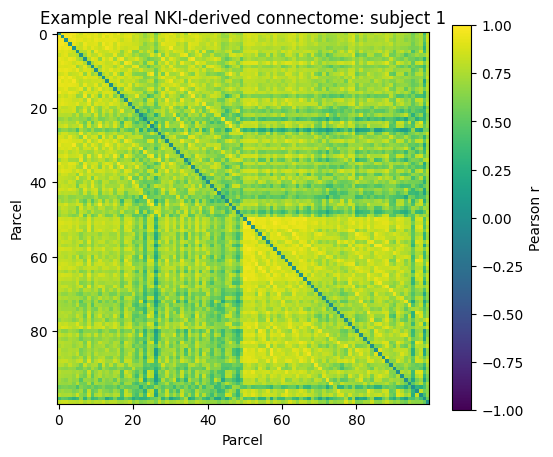

Saved: /home/john-walkey/Data/Research/connectome/figures/nki_example_connectome_subject01.png


In [8]:
plt.figure(figsize=(6, 5))
plt.imshow(connectomes[0], vmin=-1, vmax=1)
plt.colorbar(label="Pearson r")
plt.title("Example real NKI-derived connectome: subject 1")
plt.xlabel("Parcel")
plt.ylabel("Parcel")
plt.savefig(FIGURES_DIR / "nki_example_connectome_subject01.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", FIGURES_DIR / "nki_example_connectome_subject01.png")


## 5. Choose target variable

This is the key point.

Set `TARGET_COLUMN` to a real phenotype column from the printed list above.

For true trait anxiety, you want a real anxiety/STAI-like column. If none exists in the public subset, you need to obtain the richer NKI phenotype file through the DUA route, save it into `data/phenotypes/`, and merge it by subject ID.

For demonstration only, you can temporarily set a non-anxiety variable such as age if available. That is **not** your scientific hypothesis; it only tests the CPM machinery on real NKI imaging.


In [9]:
# Set this manually after inspecting pheno.columns.
# Examples might be "age" or a real anxiety/STAI column if present.
TARGET_COLUMN = None

# Helpful auto-detection:
preferred_terms = ["stai", "trait", "anx", "neurotic", "stress"]
auto_candidates = [c for c in pheno.columns if any(t in str(c).lower() for t in preferred_terms)]

print("Auto candidates:", auto_candidates)

if TARGET_COLUMN is None and auto_candidates:
    TARGET_COLUMN = auto_candidates[0]
    print("Auto-selected target:", TARGET_COLUMN)

if TARGET_COLUMN is None:
    print("No target selected.")
    print("Set TARGET_COLUMN to a real numeric phenotype column from the list above, then rerun from here.")
else:
    y_raw = pd.to_numeric(pheno[TARGET_COLUMN], errors="coerce")
    valid = y_raw.notna().values
    print("Target:", TARGET_COLUMN)
    print("Valid subjects:", valid.sum(), "/", len(valid))
    print(y_raw.describe())


Auto candidates: []
No target selected.
Set TARGET_COLUMN to a real numeric phenotype column from the list above, then rerun from here.


## 6. CPM functions

This is standard CPM logic:

1. In the training set only, correlate each edge with the behavioral target.
2. Select positive and negative edges below a p-value threshold.
3. Sum selected edge strengths per subject.
4. Fit regression in training subjects.
5. Predict held-out subject.
6. Repeat with leave-one-out cross-validation.


In [10]:
def vectorize_upper_triangle(mats):
    n_subs, n_nodes, _ = mats.shape
    iu = np.triu_indices(n_nodes, k=1)
    X = mats[:, iu[0], iu[1]]
    return X, iu

def cpm_leave_one_out(connectomes, y, p_thresh=0.01):
    X, iu = vectorize_upper_triangle(connectomes)
    y = np.asarray(y, dtype=float)
    loo = LeaveOneOut()

    y_pred = np.zeros_like(y, dtype=float)
    pos_masks = []
    neg_masks = []

    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]

        r_vals = np.zeros(X.shape[1])
        p_vals = np.ones(X.shape[1])

        for e in range(X.shape[1]):
            if np.std(X_train[:, e]) == 0:
                continue
            r_vals[e], p_vals[e] = pearsonr(X_train[:, e], y_train)

        pos_mask = (r_vals > 0) & (p_vals < p_thresh)
        neg_mask = (r_vals < 0) & (p_vals < p_thresh)

        pos_masks.append(pos_mask)
        neg_masks.append(neg_mask)

        # If no edges survive, use zero network strength for that fold.
        train_pos_strength = X_train[:, pos_mask].sum(axis=1) if pos_mask.any() else np.zeros(len(train_idx))
        train_neg_strength = X_train[:, neg_mask].sum(axis=1) if neg_mask.any() else np.zeros(len(train_idx))
        test_pos_strength = X_test[:, pos_mask].sum(axis=1) if pos_mask.any() else np.zeros(len(test_idx))
        test_neg_strength = X_test[:, neg_mask].sum(axis=1) if neg_mask.any() else np.zeros(len(test_idx))

        # Combined model with positive and negative network strength
        train_features = np.column_stack([train_pos_strength, train_neg_strength])
        test_features = np.column_stack([test_pos_strength, test_neg_strength])

        model = LinearRegression()
        model.fit(train_features, y_train)
        y_pred[test_idx] = model.predict(test_features)

    return y_pred, pos_masks, neg_masks, iu


In [12]:
print(pheno.columns)

Index(['Subject', 'Age', 'Dominant Hand', 'Sex'], dtype='str')


In [15]:
TARGET_COLUMN = "Age"

In [17]:
print("Connectomes shape:", connectomes.shape)
print("Pheno shape:", pheno.shape)

Connectomes shape: (24, 100, 100)
Pheno shape: (23, 4)


In [18]:
if TARGET_COLUMN is None:
    raise ValueError("No TARGET_COLUMN selected. Choose a real numeric phenotype column first.")

# Match lengths (quick fix)
n = min(len(connectomes), len(pheno))

connectomes = connectomes[:n]
pheno = pheno.iloc[:n]

y_all = pd.to_numeric(pheno[TARGET_COLUMN], errors="coerce").values
valid = np.isfinite(y_all)

conn_valid = connectomes[valid]
y = y_all[valid]
subject_ids = np.arange(len(y_all))[valid]

print("Running CPM on", len(y), "subjects")
print("Target:", TARGET_COLUMN)

if len(y) < 12:
    raise ValueError("Too few valid subjects for CPM. Choose a variable with more valid data or fetch more subjects.")

y_pred, pos_masks, neg_masks, iu = cpm_leave_one_out(conn_valid, y, p_thresh=0.01)

r, p = pearsonr(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"Predicted vs actual r = {r:.3f}, p = {p:.4f}")
print(f"MAE = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")


Running CPM on 23 subjects
Target: Age
Predicted vs actual r = 0.190, p = 0.3854
MAE = 11.998
RMSE = 14.755


In [ ]:
pred_df = pd.DataFrame({
    "subject_index": subject_ids,
    "actual": y,
    "predicted": y_pred,
    "target_column": TARGET_COLUMN
})
pred_path = RESULTS_DIR / f"nki_cpm_predictions_{TARGET_COLUMN}.csv"
pred_df.to_csv(pred_path, index=False)

plt.figure(figsize=(6, 5))
plt.scatter(y, y_pred)
plt.xlabel(f"Actual {TARGET_COLUMN}")
plt.ylabel(f"Predicted {TARGET_COLUMN}")
plt.title(f"NKI real-data CPM: r={r:.2f}, p={p:.3f}")

# Add best fit line for visualization
m, b = np.polyfit(y, y_pred, 1)
x_line = np.linspace(np.min(y), np.max(y), 100)
plt.plot(x_line, m * x_line + b)

fig_path = FIGURES_DIR / f"nki_cpm_predicted_vs_actual_{TARGET_COLUMN}.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", pred_path)
print("Saved:", fig_path)


## 7. Interpret honestly

If this gives a low or non-significant result, that is normal.

With only 24 subjects, CPM is unstable. A very high score would be suspicious unless you are predicting something obvious or there is leakage.

For your real anxiety project, the next serious upgrades are:

1. Use more subjects.
2. Use a proper anatomical/parcellation atlas.
3. Obtain true trait-anxiety/STAI-like phenotypes through the appropriate NKI phenotype access route.
4. Control for motion, age, sex, and possibly site/session.
5. Use nested cross-validation or an independent holdout set.
6. Only interpret insula–DMN edges after validation, not before.
